In [18]:
# 1. ربط Google Drive
# ستظهر لك نافذة تطلب الإذن بالوصول لملفاتك، وافق عليها.
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
ROOT_FOLDER = '/content/drive/MyDrive/Colab Notebooks/PetImageClassification'

In [78]:
# 3. تحميل نموذج SavedModel (متوافق مع Keras 3)
import tensorflow as tf
import keras  # كيراتس 3

MODEL_DIR = ROOT_FOLDER + "/models/pet_image_classifier"  # المجلد الذي يحتوي saved_model.pb

model = keras.layers.TFSMLayer(
    MODEL_DIR,
    call_endpoint="serving_default"  # لو أعطى خطأ نغير الاسم حسب التوقيع
)


In [17]:
class_names = [
    "Abyssinian",                    # 0
    "Bengal",                        # 1
    "Birman",                        # 2
    "Bombay",                        # 3
    "British Shorthair",            # 4
    "Egyptian Mau",                 # 5
    "Maine Coon",                   # 6
    "Persian",                      # 7
    "Ragdoll",                      # 8
    "Russian Blue",                 # 9
    "Siamese",                      # 10
    "Sphynx",                       # 11
    "american bulldog",             # 12
    "american pit bull terrier",    # 13
    "basset hound",                 # 14
    "beagle",                       # 15
    "boxer",                        # 16
    "chihuahua",                    # 17
    "english cocker spaniel",       # 18
    "english setter",               # 19
    "german shorthaired",           # 20
    "great pyrenees",               # 21
    "havanese",                     # 22
    "japanese chin",                # 23
    "keeshond",                     # 24
    "leonberger",                   # 25
    "miniature pinscher",           # 26
    "newfoundland",                 # 27
    "pomeranian",                   # 28
    "pug",                          # 29
    "saint bernard",                # 30
    "samoyed",                      # 31
    "scottish terrier",             # 32
    "shiba inu",                    # 33
    "staffordshire bull terrier",   # 34
    "wheaten terrier",              # 35
    "yorkshire terrier"             # 36
]

from google.colab import files
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# إعدادات الصورة حسب التدريب
IMG_SIZE = (256, 256)  # غيّرها لو كنت مدرّب على حجم آخر



Saving Birman_83.jpg to Birman_83.jpg


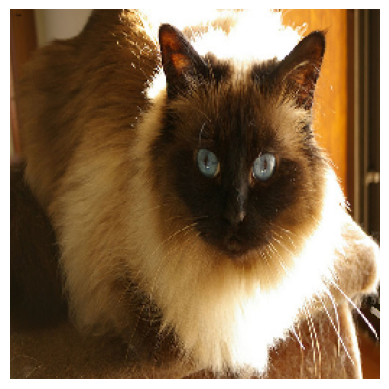

Prediction: Birman  - Confidence: 0.711791455745697


In [30]:
uploaded = files.upload()  # اختر الصور من جهازك

for file_name in uploaded.keys():
    # تحميل الصورة
    img = load_img(file_name, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # نفس الـ Normalization المستخدم في التدريب
    img_array = np.expand_dims(img_array, axis=0)

    # التنبؤ باستخدام TFSMLayer
    outputs = model(img_array)                 # dict: key -> tensor
    preds = list(outputs.values())[0].numpy()  # (1, num_classes)

    pred_idx = np.argmax(preds[0])
    pred_class = class_names[pred_idx]
    confidence = float(np.max(preds[0]))

    # عرض الصورة
    plt.imshow(img)
    plt.axis('off')

    # كتابة الاسم والنسبة تحت الصورة (أو جنبها)
    text = f"{pred_class} ({confidence:.2f})"
    plt.xlabel(text, fontsize=12)  # تحت الصورة

    # لو بدك يكون فوق يسار مثلاً بدل xlabel:
    # plt.text(0.01, 0.99, text, transform=plt.gca().transAxes,
    #          va='top', ha='left', fontsize=12,
    #          bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    plt.show()

    # ولو حاب تطبعها في الـ output كنص مستقل كمان:
    print("Prediction:", pred_class, " - Confidence:", confidence)



In [ ]:
import numpy as np

# جرّب إدخال عينة وهمية بنفس شكل الصورة
dummy = np.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3), dtype="float32")
outputs = model(dummy)
preds = list(outputs.values())[0].numpy()
print("preds shape:", preds.shape)
print("preds[0]:", preds[0])


preds shape: (1, 37)
preds[0]: [1.8713345e-01 2.1009574e-02 2.2725353e-04 7.5033970e-02 1.5486372e-02
 4.0008251e-02 1.1092572e-01 2.1149106e-01 9.2412317e-03 3.5267726e-02
 3.4866235e-04 8.4919356e-02 5.9404172e-04 9.9160923e-03 2.4204468e-04
 1.8957276e-04 2.6817594e-04 4.2350078e-03 1.1435024e-03 1.2885685e-03
 5.3453939e-03 1.6830346e-03 3.1710849e-03 1.5597815e-04 1.6624617e-03
 5.9414486e-04 6.2594330e-03 2.9518344e-02 1.2805232e-02 7.6171746e-05
 2.8659540e-06 7.2413622e-03 5.8594681e-02 3.0378683e-03 3.0603295e-04
 4.2221140e-02 1.8355133e-02]


In [36]:
import tensorflow as tf

SAVED_MODEL_DIR = "/content/drive/MyDrive/Colab Notebooks/PetImageClassification/models/pet_image_classifier"

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
# (اختياري لكن مهم للجوال: تصغير الحجم)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# حفظ الملف

OUT_PATH = "/content/drive/MyDrive/Colab Notebooks/PetImageClassification/tf models/pet_image_classifier.tflite"

with open(OUT_PATH, "wb") as f:
    f.write(tflite_model)

print("Saved TFLite model to:", OUT_PATH)

with open("pet_image_classifier.tflite", "wb") as f:
    f.write(tflite_model)


Saved TFLite model to: /content/drive/MyDrive/Colab Notebooks/PetImageClassification/tf models/pet_image_classifier.tflite


In [37]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

TFLITE_PATH = "/content/drive/MyDrive/Colab Notebooks/PetImageClassification/tf models/pet_image_classifier.tflite"

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details)
print("Output:", output_details)


Input: [{'name': 'serving_default_conv2d_input:0', 'index': 0, 'shape': array([  1, 256, 256,   3], dtype=int32), 'shape_signature': array([ -1, 256, 256,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'StatefulPartitionedCall:0', 'index': 74, 'shape': array([ 1, 37], dtype=int32), 'shape_signature': array([-1, 37], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [38]:
IMG_SIZE = (256, 256)

class_names = [
    "Abyssinian","Bengal","Birman","Bombay","British Shorthair",
    "Egyptian Mau","Maine Coon","Persian","Ragdoll","Russian Blue",
    "Siamese","Sphynx","american bulldog","american pit bull terrier",
    "basset hound","beagle","boxer","chihuahua","english cocker spaniel",
    "english setter","german shorthaired","great pyrenees","havanese",
    "japanese chin","keeshond","leonberger","miniature pinscher",
    "newfoundland","pomeranian","pug","saint bernard","samoyed",
    "scottish terrier","shiba inu","staffordshire bull terrier",
    "wheaten terrier","yorkshire terrier"
]

def predict_tflite(image_path):
    # تحميل الصورة وتحضيرها
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # ضبط نوع البيانات حسب ما يتوقعه الموديل
    input_data = img_array.astype(input_details[0]["dtype"])

    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()

    preds = interpreter.get_tensor(output_details[0]["index"])[0]  # shape: (37,)
    pred_idx = np.argmax(preds)
    pred_class = class_names[pred_idx]
    confidence = float(np.max(preds))

    # عرض الصورة مع النتيجة
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {pred_class} ({confidence:.2f})")
    plt.show()

    print("Index:", pred_idx, "Class:", pred_class, "Confidence:", confidence)


Saving WhatsApp Image 2026-01-17 at 4.32.19 AM.jpeg to WhatsApp Image 2026-01-17 at 4.32.19 AM (4).jpeg
Testing: WhatsApp Image 2026-01-17 at 4.32.19 AM (4).jpeg


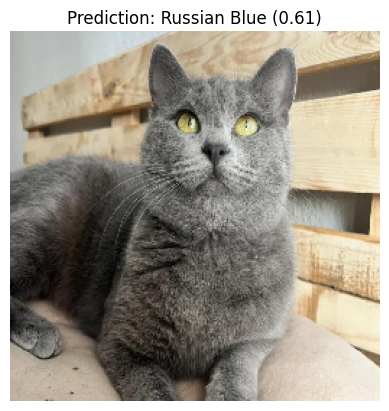

Index: 9 Class: Russian Blue Confidence: 0.6124871373176575


In [42]:
from google.colab import files

uploaded = files.upload()

for name in uploaded.keys():
    print("Testing:", name)
    predict_tflite(name)


In [49]:
import cv2
import numpy as np
import os
from google.colab import files
from matplotlib import pyplot as plt

def image_descriptor(path):
    # قراءة الصورة
    img = cv2.imread(path)
    img = cv2.resize(img, (128, 128))
    # تحويل لـ HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # هيستوغرام H,S,V
    hist = cv2.calcHist([hsv], [0, 1, 2], None,
                        [8, 8, 8], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def cosine_similarity(a, b):
    a = a.astype("float32")
    b = b.astype("float32")
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


In [ ]:
2) اختيار صورة الحيوان الضائع


Upload lost pet image:


Saving WhatsApp Image 2026-01-17 at 4.32.19 AM.jpeg to WhatsApp Image 2026-01-17 at 4.32.19 AM (8).jpeg
Lost image: WhatsApp Image 2026-01-17 at 4.32.19 AM (8).jpeg
Testing: WhatsApp Image 2026-01-17 at 4.32.19 AM (8).jpeg


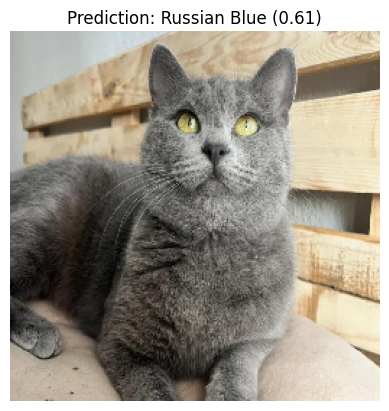

Index: 9 Class: Russian Blue Confidence: 0.6124871373176575


In [65]:
# اختيار صورة واحدة (الحيوان الضائع)
print("Upload lost pet image:")
uploaded = files.upload()

lost_image_path = None
for name in uploaded.keys():
    lost_image_path = name
    break  # أول ملف فقط

print("Lost image:", lost_image_path)

lost_desc = image_descriptor(lost_image_path)

for name in uploaded.keys():
    print("Testing:", name)
    predict_tflite(name)


In [66]:
# مجلد الحيوانات من نفس الفصيلة (عدّل المسار حسب ملفاتك)
BREED_DIR = "/content/drive/MyDrive/Colab Notebooks/PetImageClassification/same_breed"

breed_images = []
for fname in os.listdir(BREED_DIR):
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        full_path = os.path.join(BREED_DIR, fname)
        breed_images.append({
            "name": os.path.splitext(fname)[0],  # اسم بدون الامتداد
            "path": full_path
        })

print("Total breed images:", len(breed_images))


Total breed images: 21


In [ ]:
4) حساب التشابه وإرجاع أقرب 5


In [67]:
def top_k_similar(lost_desc, breed_images, k=5):
    results = []
    for item in breed_images:
        desc = image_descriptor(item["path"])
        sim = cosine_similarity(lost_desc, desc)
        results.append((sim, item))

    # ترتيب من الأعلى تشابهًا
    results.sort(reverse=True, key=lambda x: x[0])
    return results[:k]


In [68]:
top5 = top_k_similar(lost_desc, breed_images, k=5)

print("Top 5 similar images:")
for sim, item in top5:
    print(f"{item['name']} -> similarity: {sim:.3f}")


Top 5 similar images:
WhatsApp Image 2026-01-17 at 4.32.19 AM -> similarity: 1.000
Russian_Blue_130 -> similarity: 0.594
Russian_Blue_147 -> similarity: 0.507
Russian_Blue_129 -> similarity: 0.469
Russian_Blue_145 -> similarity: 0.437


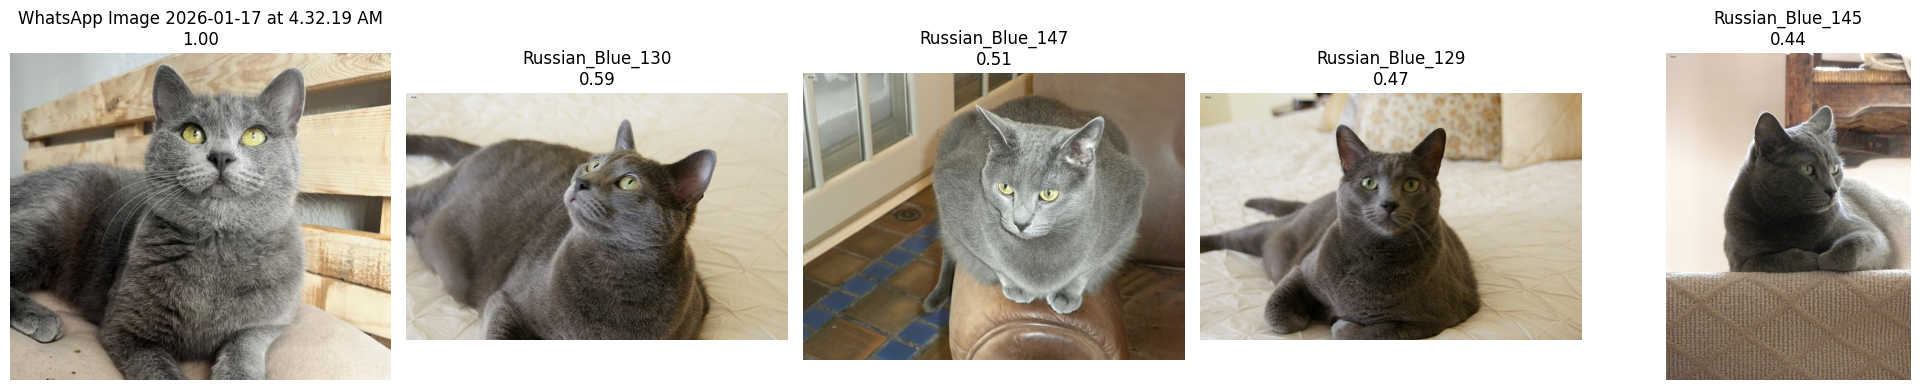

In [69]:
fig, axes = plt.subplots(1, len(top5), figsize=(4*len(top5), 4))

if len(top5) == 1:
    axes = [axes]

for ax, (sim, item) in zip(axes, top5):
    img = cv2.imread(item["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{item['name']}\n{sim:.2f}")

plt.tight_layout()
plt.show()


In [71]:
import tensorflow as tf

TFLITE_PATH = "/content/drive/MyDrive/Colab Notebooks/PetImageClassification/tf models/pet_image_classifier.tflite"

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

tensor_details = interpreter.get_tensor_details()

print("Total tensors:", len(tensor_details))
for t in tensor_details:
    print(
        "name:", t["name"],
        "| index:", t["index"],
        "| shape:", t["shape"],
        "| dtype:", t["dtype"]
    )


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Total tensors: 75
name: serving_default_conv2d_input:0 | index: 0 | shape: [  1 256 256   3] | dtype: <class 'numpy.float32'>
name: arith.constant | index: 1 | shape: [32] | dtype: <class 'numpy.float32'>
name: arith.constant1 | index: 2 | shape: [2] | dtype: <class 'numpy.int32'>
name: arith.constant2 | index: 3 | shape: [256] | dtype: <class 'numpy.float32'>
name: arith.constant3 | index: 4 | shape: [37] | dtype: <class 'numpy.float32'>
name: arith.constant4 | index: 5 | shape: [64] | dtype: <class 'numpy.float32'>
name: arith.constant5 | index: 6 | shape: [64] | dtype: <class 'numpy.float32'>
name: arith.constant6 | index: 7 | shape: [32] | dtype: <class 'numpy.float32'>
name: arith.constant7 | index: 8 | shape: [32] | dtype: <class 'numpy.float32'>
name: arith.constant8 | index: 9 | shape: [32] | dtype: <class 'numpy.float32'>
name: arith.constant9 | index: 10 | shape: [64] | dtype: <class 'numpy.float32'>
name: arith.constant10 | index: 11 | shape: [64] | dtype: <class 'numpy.floa